<a href="https://colab.research.google.com/github/sonalsinghk/HandsOnML/blob/main/2_end_to_end_ml_sonal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")

    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)

        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)

        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")

    return pd.read_csv(Path("datasets/housing/housing.csv"))

housing_full = load_housing_data()

/tmp/ipykernel_1612/3982659026.py:16: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tarball.extractall(path="datasets")


In [3]:
housing_full.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
housing_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
housing_full['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [5]:
housing_full.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


#Observations
###1.Total bedrooms - count: 20433 less than the rest.

###2. Maximum Total bedrooms - 39320 : that means they maybe taking a locality rather than a house in data.

###3.Median Income - values are 0.something that means its calculated in thousands.

###4. Median_house_value : 500k captured.



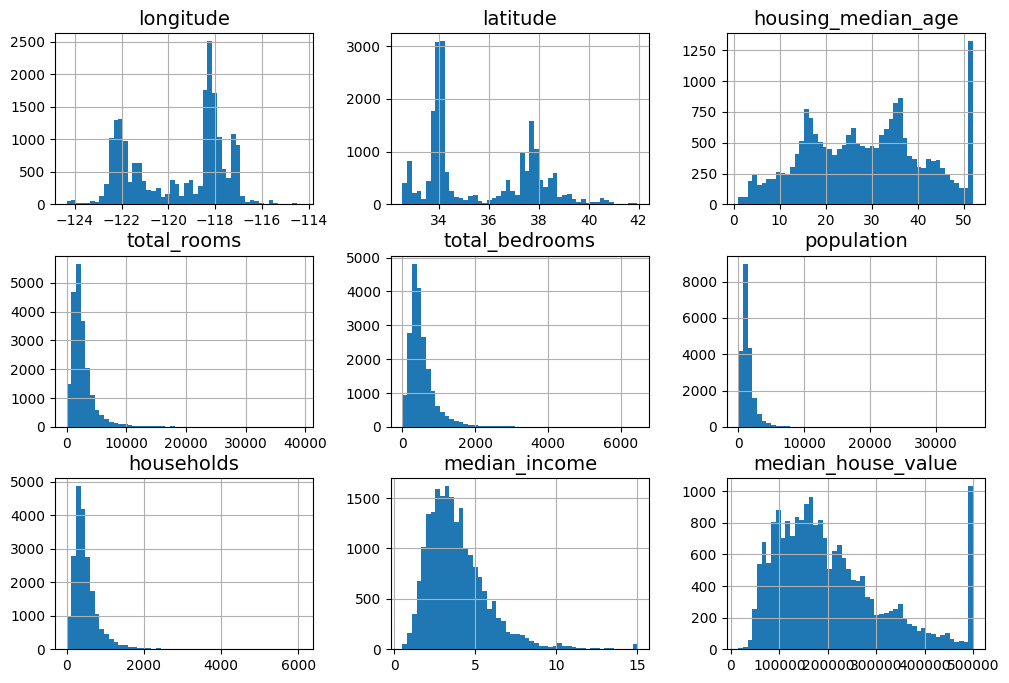

In [6]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes',labelsize=14,titlesize=14)
plt.rc('legend',fontsize=20)
plt.rc('xtick',labelsize=10)
plt.rc('ytick',labelsize=10)


housing_full.hist(bins=50,figsize=(12,8))

plt.show()

#CREATE A TEST SET

In [7]:
import numpy as np

def shuffle_and_split_data(data,test_ratio,rng):
  shuffled_indices = rng.permutation(len(data))
  test_set_size = int(len(data) * test_ratio)
  test_indices = shuffled_indices[:test_set_size]
  train_indices = shuffled_indices[test_set_size:]
  return data.iloc[train_indices],data.iloc[test_indices]

In [8]:
rng = np.random.default_rng(seed=42)
train_set, test_set = shuffle_and_split_data(housing_full,0.2,rng)
len(train_set)


16512

In [9]:
len(test_set)

4128

Note: another source of randomness is the order of Python sets: it is based on Python's `hash()` function, which is randomly "salted" when Python starts up (this started in Python 3.3, to prevent some denial-of-service attacks). To remove this randomness, the solution is to set the `PYTHONHASHSEED` environment variable to `"0"` _before_ Python even starts up. Nothing will happen if you do it after that. Luckily, if you're running this notebook on Colab, the variable is already set for you.

Every time the above program runs, new test set will be generated each time. One solution is to save the test set on the first run and then load it in subsequent runs. Another sol^n is to set the random generator seed (by passing seed = 42 or default_rng) to ensure it generates the same number of sequence of random numbers everytime you run the program.

However both this solutions will break if you fetch an updated dataset. To have a stable train/test split even after updating the dataset, a common solution is to use each **instance's identifier** to decide whether it should go in the test set.
For example, You could compute a hash of each instance's identifier and put that instance in the test set **if the hash is lower than or equal to 20% of the maximum hash value**.This ensures that the test set will remain consistent accross multiple runs, even if you refresh the dataset.
**The new test set will contain 20% of the new instances, but it will not contain any instance that was previously in the training set.**

In [10]:
from zlib import crc32

def is_id_in_test_set(identifier,test_ratio):
  return crc32(np.int64(identifier)) < test_ratio * 2**32

def split_data_with_id_hash(data,test_ratio,id_column):
  ids = data[id_column]
  in_test_set = ids.apply(lambda id_: is_id_in_test_set(id_,test_ratio))
  return data.loc[~in_test_set], data.loc[in_test_set]

Unfortunately, the housing dataset doesn't have a identifier column. The simplest solution is to use the row index as ID:

In [11]:
housing_with_id = housing_full.reset_index() # adds an `index` column
train_set, test_set = split_data_with_id_hash(housing_with_id,0.2,"index")

If you use the row index as unique identifier, you need to make sure that new data gets appended to the end of the dataset and that no row ever gets deleted. If this is not possible, then you can try to use the most stable features to build a unique identifier.
For example, longitude and latitude are gauranteed to be stable for a few million years, so you could combine them into an ID like so:



In [12]:
housing_with_id["id"] = (housing_full["longitude"] * 1000
                         + housing_full["latitude"])
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, "id")

In [13]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing_full, test_size=0.2,
                                       random_state=42)

In [14]:
test_set["total_bedrooms"].isnull().sum()

np.int64(44)

**Stratified Sampling**
Dividing the data into subgroups (strata) and the right number of instances are sampled from each stratum to gaurantee that the test set is representative of the overall population.

The following code uses the pd.cut() to create an income category attribute with five categories (labeled from 1 to 5); category 1 ranges from 0 to 1.5 (less than $15,000), category 2 from 1.5 to 3, and so on:

In [15]:
housing_full["income_cat"] = pd.cut(housing_full["median_income"],
                                    bins = [0.,1.5,3.0,4.5,6.,np.inf],
                                    labels = [1,2,3,4,5])

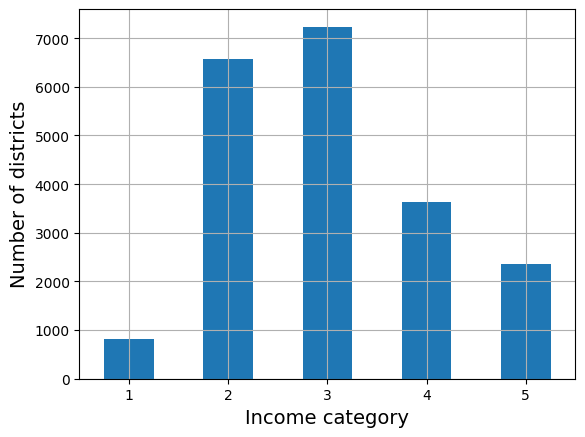

In [18]:
cat_counts = housing_full["income_cat"].value_counts().sort_index()
cat_counts.plot.bar(rot=0, grid = True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")

plt.show()